# Logistic regression to predict categories

In [1]:
# Import required library

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

full_pumpkins = pd.read_csv('../data/US-pumpkins.csv')

full_pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [2]:
# Select only the features needed

columns_to_select = ['City Name','Package','Variety', 'Origin','Item Size', 'Color']
pumpkins = full_pumpkins.loc[:, columns_to_select]

pumpkins.dropna(inplace=True)

pumpkins.info

<bound method DataFrame.info of       City Name       Package            Variety    Origin Item Size   Color
2     BALTIMORE  24 inch bins        HOWDEN TYPE  DELAWARE       med  ORANGE
3     BALTIMORE  24 inch bins        HOWDEN TYPE  VIRGINIA       med  ORANGE
4     BALTIMORE  24 inch bins        HOWDEN TYPE  MARYLAND       lge  ORANGE
5     BALTIMORE  24 inch bins        HOWDEN TYPE  MARYLAND       lge  ORANGE
6     BALTIMORE  36 inch bins        HOWDEN TYPE  MARYLAND       med  ORANGE
...         ...           ...                ...       ...       ...     ...
1694  ST. LOUIS  24 inch bins  HOWDEN WHITE TYPE  ILLINOIS      xlge   WHITE
1695  ST. LOUIS  24 inch bins  HOWDEN WHITE TYPE  ILLINOIS      xlge   WHITE
1696  ST. LOUIS  24 inch bins  HOWDEN WHITE TYPE  ILLINOIS      xlge   WHITE
1697  ST. LOUIS  24 inch bins  HOWDEN WHITE TYPE  ILLINOIS      xlge   WHITE
1698  ST. LOUIS  24 inch bins  HOWDEN WHITE TYPE  ILLINOIS      xlge   WHITE

[991 rows x 6 columns]>

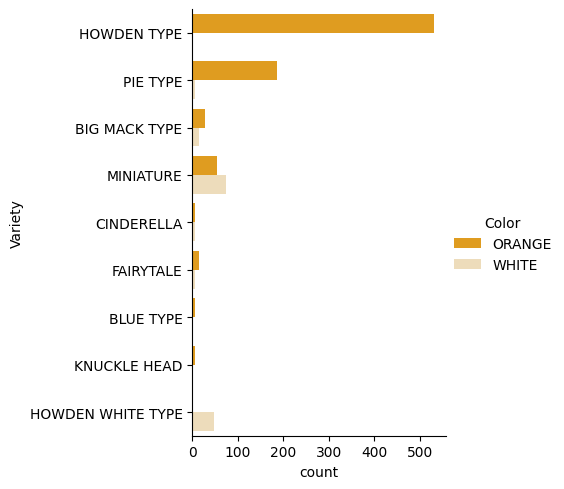

In [3]:
# Specifying a color mapping for each pumpkin category (orange or white)

import seaborn as sns

palette = {
'ORANGE': 'orange',
'WHITE': 'wheat',
}

sns.catplot(data=pumpkins, y="Variety", hue="Color", kind="count", palette=palette)

In [4]:
# Suits well on categorical variables where their data follows a logical ordering

from sklearn.preprocessing import OrdinalEncoder

item_size_categories = [['sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo']]
ordinal_features = ['Item Size']
ordinal_encoder = OrdinalEncoder(categories=item_size_categories)

In [5]:
# Suits well on categorical variables where their data does not follow a logical ordering

from sklearn.preprocessing import OneHotEncoder

categorical_features = ['City Name', 'Package', 'Variety', 'Origin']
categorical_encoder = OneHotEncoder(sparse_output=False)

In [6]:
# Combine multiple encoders into a single step and apply them to the appropriate columns

from sklearn.compose import ColumnTransformer
    
ct = ColumnTransformer(transformers=[
    ('ord', ordinal_encoder, ordinal_features),
    ('cat', categorical_encoder, categorical_features)
    ])
    
ct.set_output(transform='pandas')
encoded_features = ct.fit_transform(pumpkins)

In [7]:
# Encode label and merge them into a new df (encoded_pumpkins)

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
encoded_label = label_encoder.fit_transform(pumpkins['Color'])

encoded_pumpkins = encoded_features.assign(Color=encoded_label)

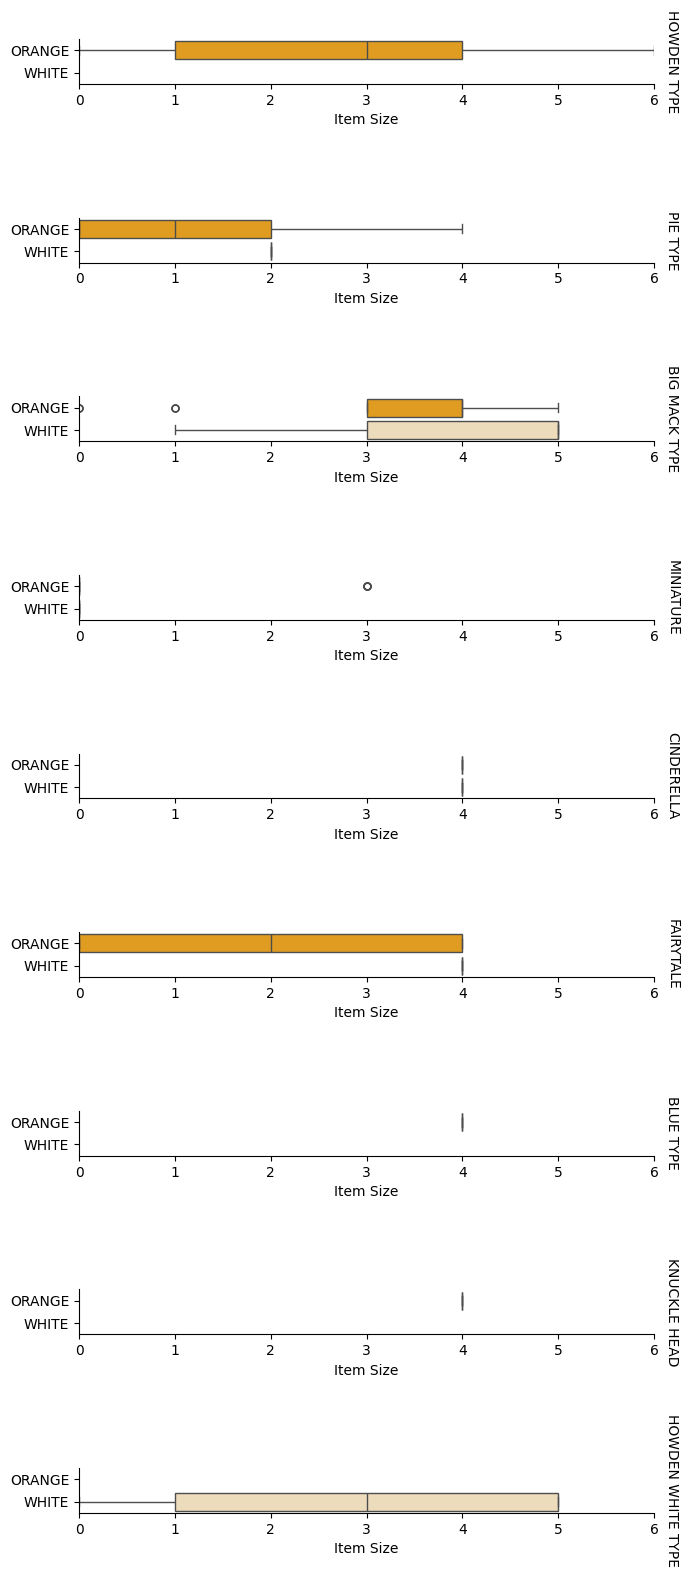

In [8]:
# Visualize the relationships between Item Size, Variety and Color in a categorical plot

palette = {
'ORANGE': 'orange',
'WHITE': 'wheat',
}
pumpkins['Item Size'] = encoded_pumpkins['ord__Item Size']

g = sns.catplot(
    data=pumpkins,
    x="Item Size", y="Color", hue="Color", row='Variety',
    kind="box", orient="h",
    sharex=False, margin_titles=True,
    height=1.8, aspect=4, palette=palette,
    legend=False
)
g.set(xlabel="Item Size", ylabel="").set(xlim=(0,6))
g.set_titles(row_template="{row_name}")

/home/berdangry/Workspace/docs/projects/ml-notes/venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 63.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/berdangry/Workspace/docs/projects/ml-notes/venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 21.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Color', ylabel='ord__Item Size'>

/home/berdangry/Workspace/docs/projects/ml-notes/venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 79.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/berdangry/Workspace/docs/projects/ml-notes/venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 35.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


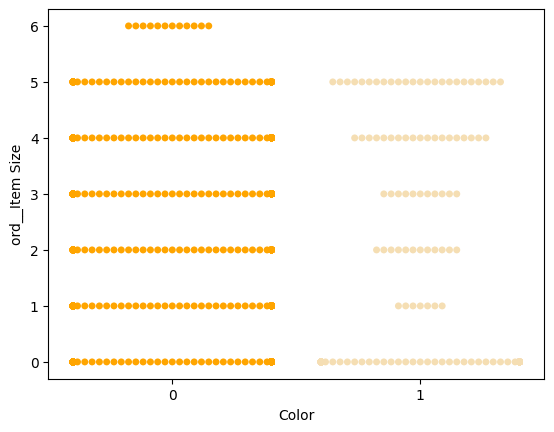

In [9]:
# Using swarmplot to see the distribution between orange and white pump

palette = {
0: 'orange',
1: 'wheat'
}
sns.swarmplot(x="Color", y="ord__Item Size", hue="Color", data=encoded_pumpkins, palette=palette, legend=False)

### Build a model

In [10]:
# Split train and test sets

from sklearn.model_selection import train_test_split

X = encoded_pumpkins[encoded_pumpkins.columns.difference(['Color'])]
y = encoded_pumpkins['Color']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [11]:
# Train model with train sets and predict

from sklearn.metrics import f1_score, classification_report 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(classification_report(y_test, predictions))
print('Predicted labels: ', predictions)
print('F1-score: ', f1_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       166
           1       0.85      0.67      0.75        33

    accuracy                           0.92       199
   macro avg       0.89      0.82      0.85       199
weighted avg       0.92      0.92      0.92       199

Predicted labels:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 1 1]
F1-score:  0.7457627118644068


In [12]:
# Comprehension via a confusion matrix

from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions)

array([[162,   4],
       [ 11,  22]])

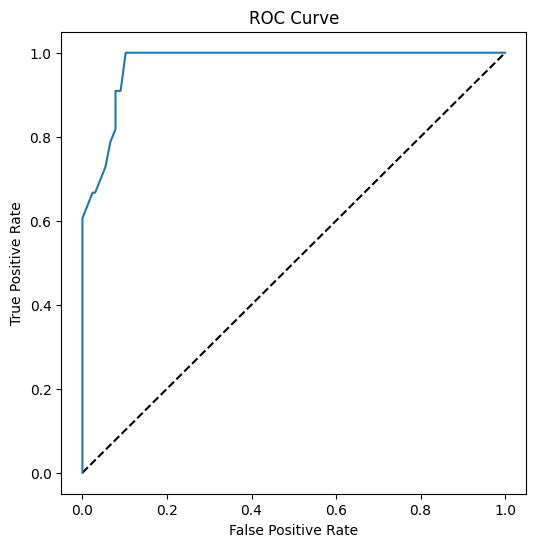

In [13]:
# Visualization to see roc curve

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

y_scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [14]:
# ROC auc score

auc = roc_auc_score(y_test,y_scores[:,1])
print(auc)

0.9749908725812341


### Assignment

In the lesson, you used a subset of the pumpkin data. Now, go back to the original data and try to use all of it, cleaned and standardized, to build a Logistic Regression model.

In [15]:
full_pumpkins = pd.read_csv('../data/US-pumpkins.csv')

full_pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [16]:
full_pumpkins = full_pumpkins.drop(columns=['Unnamed: 24','Unnamed: 25'], errors='ignore')
full_pumpkins.isnull().sum()

City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
dtype: int64

In [17]:
threshold = 0.8
missing_ratio = full_pumpkins.isnull().mean()

cols_to_drop = missing_ratio[missing_ratio > threshold].index
full_pumpkins = full_pumpkins.drop(columns=cols_to_drop)

full_pumpkins = full_pumpkins.loc[:, ~full_pumpkins.columns.str.contains('^Unnamed')]

In [18]:
print(full_pumpkins['Low Price'].corr(full_pumpkins['Mostly Low']))
print(full_pumpkins['High Price'].corr(full_pumpkins['Mostly High']))

0.9975426540164651
0.9961743310714093


In [19]:
full_pumpkins['Price'] = (full_pumpkins['Low Price'] + full_pumpkins['High Price']) / 2

cols_to_drop = ['Mostly Low', 'Mostly High', 'Low Price', 'High Price']
full_pumpkins = full_pumpkins.drop(columns=cols_to_drop)

In [20]:
full_pumpkins['Date'] = pd.to_datetime(full_pumpkins['Date'])
full_pumpkins['Month'] = full_pumpkins['Date'].dt.month

full_pumpkins = full_pumpkins.drop(columns=['Date'])

/tmp/ipykernel_602298/2020424195.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  full_pumpkins['Date'] = pd.to_datetime(full_pumpkins['Date'])


In [21]:
full_pumpkins.head()

,City Name,Package,Variety,Origin,Item Size,Color,Repack,Price,Month
0,BALTIMORE,24 inch bins,NaN,MARYLAND,lge,NaN,E,275.0,4
1,BALTIMORE,24 inch bins,NaN,MARYLAND,lge,NaN,E,275.0,5
2,BALTIMORE,24 inch bins,HOWDEN TYPE,DELAWARE,med,ORANGE,N,160.0,9
3,BALTIMORE,24 inch bins,HOWDEN TYPE,VIRGINIA,med,ORANGE,N,160.0,9
4,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE,N,95.0,11


In [22]:
new_pumpkins = full_pumpkins[full_pumpkins['Package'].str.contains('bushel', case=True, regex=True)]
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = full_pumpkins['Price']/(1 + 1/9)
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = full_pumpkins['Price']/(1/2)
print(new_pumpkins)

      City Name               Package    Variety    Origin Item Size   Color  \
70    BALTIMORE  1 1/9 bushel cartons   PIE TYPE  DELAWARE       med  ORANGE   
71    BALTIMORE  1 1/9 bushel cartons   PIE TYPE  DELAWARE       sml  ORANGE   
72    BALTIMORE  1 1/9 bushel cartons   PIE TYPE  DELAWARE       sml  ORANGE   
73    BALTIMORE  1 1/9 bushel cartons   PIE TYPE      OHIO       med  ORANGE   
74    BALTIMORE  1 1/9 bushel cartons   PIE TYPE  DELAWARE       NaN  ORANGE   
...         ...                   ...        ...       ...       ...     ...   
1738  ST. LOUIS    1/2 bushel cartons  MINIATURE    CANADA       NaN   WHITE   
1739  ST. LOUIS    1/2 bushel cartons  MINIATURE  ILLINOIS       NaN   WHITE   
1740  ST. LOUIS    1/2 bushel cartons  MINIATURE  ILLINOIS       NaN  ORANGE   
1741  ST. LOUIS    1/2 bushel cartons  MINIATURE  MICHIGAN       NaN   WHITE   
1742  ST. LOUIS    1/2 bushel cartons  MINIATURE  MICHIGAN       NaN  ORANGE   

     Repack  Price  Month  
70        N

In [23]:
new_pumpkins.isnull().sum()

City Name      0
Package        0
Variety        0
Origin         0
Item Size    114
Color        145
Repack         0
Price          0
Month          0
dtype: int64

In [24]:
new_pumpkins.dropna(inplace=True)
print(new_pumpkins)

      City Name               Package    Variety    Origin Item Size   Color  \
70    BALTIMORE  1 1/9 bushel cartons   PIE TYPE  DELAWARE       med  ORANGE   
71    BALTIMORE  1 1/9 bushel cartons   PIE TYPE  DELAWARE       sml  ORANGE   
72    BALTIMORE  1 1/9 bushel cartons   PIE TYPE  DELAWARE       sml  ORANGE   
73    BALTIMORE  1 1/9 bushel cartons   PIE TYPE      OHIO       med  ORANGE   
75    BALTIMORE  1 1/9 bushel cartons   PIE TYPE  DELAWARE       sml  ORANGE   
...         ...                   ...        ...       ...       ...     ...   
1236   NEW YORK    1/2 bushel cartons  MINIATURE      OHIO       sml   WHITE   
1239   NEW YORK    1/2 bushel cartons  MINIATURE      OHIO       sml   WHITE   
1257    DETROIT  1 1/9 bushel cartons   PIE TYPE  MICHIGAN       med  ORANGE   
1258    DETROIT  1 1/9 bushel cartons   PIE TYPE  MICHIGAN       med  ORANGE   
1259    DETROIT  1 1/9 bushel cartons   PIE TYPE  MICHIGAN       med  ORANGE   

     Repack  Price  Month  
70        N

In [25]:
new_pumpkins['Repack'].unique()

<StringArray>
['N']
Length: 1, dtype: str

In [29]:
new_pumpkins = new_pumpkins.drop(columns=['Repack'])

In [31]:
X = new_pumpkins.drop(columns=['Color'])
y = new_pumpkins['Color']

ordinal_features = ['Item Size']
item_size_categories = [['sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo']]

categorical_features = ['City Name', 'Package', 'Variety', 'Origin']

numeric_features = ['Price', 'Month']

In [32]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=item_size_categories), ordinal_features),
        ('cat', OneHotEncoder(sparse_output=False), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

ct.set_output(transform='pandas')
encoded_features = ct.fit_transform(new_pumpkins)

In [34]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
encoded_label = label_encoder.fit_transform(new_pumpkins['Color'])

encoded_pumpkins = encoded_features.assign(Color=encoded_label)

In [40]:
from sklearn.model_selection import train_test_split

X = encoded_pumpkins[encoded_pumpkins.columns.difference(['Color'])]
y = encoded_pumpkins['Color']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

In [41]:
from sklearn.metrics import f1_score, classification_report 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(classification_report(y_test, predictions))
print('Predicted labels: ', predictions)
print('F1-score: ', f1_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.62      0.73        24
           1       0.57      0.86      0.69        14

    accuracy                           0.71        38
   macro avg       0.73      0.74      0.71        38
weighted avg       0.77      0.71      0.71        38

Predicted labels:  [0 0 1 1 0 1 1 0 1 1 0 1 1 1 1 0 0 0 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 1 1 0 1
 1]
F1-score:  0.6857142857142857


In [43]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions)

array([[15,  9],
       [ 2, 12]])

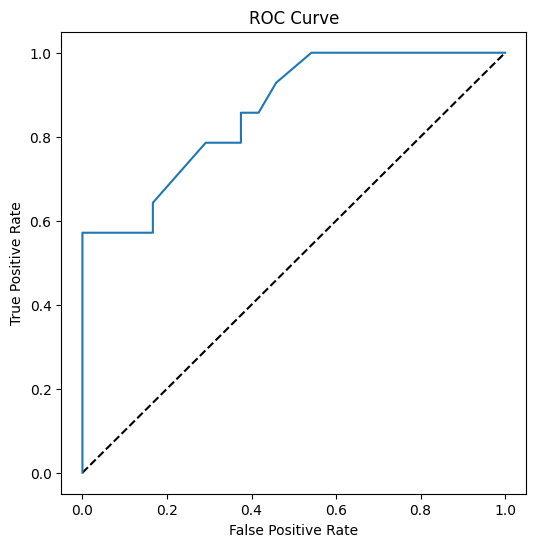

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

y_scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

Explanation:

In this assignment, I used the full original pumpkin dataset instead of a limited subset and performed proper data cleaning before building the Logistic Regression model. During preprocessing, I handled missing values by removing rows or features with excessive null entries and eliminated redundant features with high correlation to reduce multicollinearity. I also removed non-informative features; for example, after applying dropna, the Repack column contained only a single constant value “N”, so it was excluded from the model. Unlike the lesson example, I additionally included Month and Price as features in the model. After training, I achieved an F1-score of approximately 0.69 with an accuracy of around 0.71; however, this performance was slightly lower than the example in the lesson, likely because the Month and Price variables do not strongly influence the pumpkin color label and may have introduced additional noise into the model.